# Atividade — Histograma e correção de exposição

Foram escolhidas três fotos próprias:

- **foto_escura.jpg** — imagem com pouca iluminação;
- **foto_clara.jpg** — imagem com uma região muito clara/superexposta;
- **foto_bem_exposta.jpg** — imagem considerada bem exposta.

O processamento será feito em tons de cinza.

## Imports

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
try:
    from google.colab import files
except ImportError:
    files = None

## Upload das imagens

No Colab, faça o upload manual das três imagens com estes nomes:

- `foto_escura.jpg`
- `foto_clara.jpg`
- `foto_bem_exposta.jpg`

In [2]:
from pathlib import Path

nomes_imagens = [
    'foto_escura.jpg',
    'foto_clara.jpg',
    'foto_bem_exposta.jpg'
]

if all(Path(nome).exists() for nome in nomes_imagens):
    print('Imagens já disponíveis no ambiente; upload manual não necessário nesta execução.')
else:
    if files is None:
        raise FileNotFoundError('As três imagens não estão no diretório atual e o ambiente não é Google Colab.')
    arquivos = files.upload()


Imagens já disponíveis no ambiente; upload manual não necessário nesta execução.


## Leitura das imagens

In [3]:
img_escura = cv2.imread('foto_escura.jpg')
img_clara = cv2.imread('foto_clara.jpg')
img_bem_exposta = cv2.imread('foto_bem_exposta.jpg')

## Conversão para tons de cinza

In [4]:
cinza_escura = cv2.cvtColor(img_escura, cv2.COLOR_BGR2GRAY)
cinza_clara = cv2.cvtColor(img_clara, cv2.COLOR_BGR2GRAY)
cinza_bem_exposta = cv2.cvtColor(img_bem_exposta, cv2.COLOR_BGR2GRAY)

## Função para correção de gamma

In [5]:
def corrigir_gamma(imagem, gamma):
    imagem_normalizada = imagem / 255.0
    imagem_corrigida = 255 * (imagem_normalizada ** gamma)
    return imagem_corrigida.astype(np.uint8)

## 1. Imagem escura

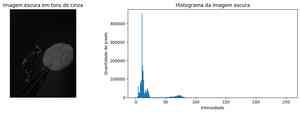

In [6]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.imshow(cinza_escura, cmap='gray', vmin=0, vmax=255)
plt.title('Imagem escura em tons de cinza')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.hist(cinza_escura.ravel(), bins=256, range=(0, 256))
plt.title('Histograma da imagem escura')
plt.xlabel('Intensidade')
plt.ylabel('Quantidade de pixels')

plt.tight_layout()
plt.show()

**Diagnóstico:** o histograma está fortemente concentrado nas intensidades baixas, principalmente abaixo de 64, com pico próximo de 10. Isso indica que a maior parte da imagem é muito escura e possui pouca informação nas regiões de maior intensidade.

**Operação escolhida:** correção de gamma com **γ = 0,55**. Como γ < 1, a transformação aumenta as intensidades dos pixels escuros, clareando a imagem.

In [7]:
gamma_escura = 0.55
escura_corrigida = corrigir_gamma(cinza_escura, gamma_escura)

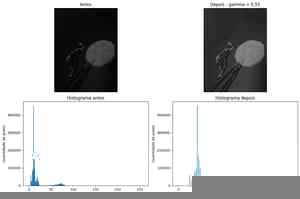

In [8]:
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.imshow(cinza_escura, cmap='gray', vmin=0, vmax=255)
plt.title('Antes')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(escura_corrigida, cmap='gray', vmin=0, vmax=255)
plt.title('Depois - gamma = 0,55')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.hist(cinza_escura.ravel(), bins=256, range=(0, 256))
plt.title('Histograma antes')
plt.xlabel('Intensidade')
plt.ylabel('Quantidade de pixels')

plt.subplot(2, 2, 4)
plt.hist(escura_corrigida.ravel(), bins=256, range=(0, 256))
plt.title('Histograma depois')
plt.xlabel('Intensidade')
plt.ylabel('Quantidade de pixels')

plt.tight_layout()
plt.show()

## 2. Imagem clara / superexposta

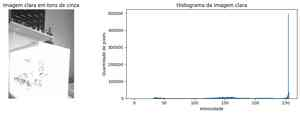

In [9]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.imshow(cinza_clara, cmap='gray', vmin=0, vmax=255)
plt.title('Imagem clara em tons de cinza')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.hist(cinza_clara.ravel(), bins=256, range=(0, 256))
plt.title('Histograma da imagem clara')
plt.xlabel('Intensidade')
plt.ylabel('Quantidade de pixels')

plt.tight_layout()
plt.show()

**Diagnóstico:** o histograma apresenta forte concentração nas intensidades altas, especialmente próximas ao limite superior de 255, caracterizando superexposição e saturação das regiões mais iluminadas. Na imagem original, a intensidade média é aproximadamente **195,76**, e cerca de **48,4% dos pixels possuem intensidade maior ou igual a 240**. Por isso, parte dos detalhes das áreas mais claras já foi perdida na captura.

**Operação escolhida:** correção de gamma com **γ = 2,00**. O valor **γ = 1,20** foi testado, mas produziu uma alteração visual muito discreta, reduzindo a intensidade média apenas para aproximadamente **188,22**. Com **γ = 2,00**, a média passa para cerca de **168,45**, tornando a correção perceptível sem o escurecimento excessivo observado com valores mais altos. Como γ > 1, a transformação reduz as intensidades intermediárias e altas. Os pixels que já estavam saturados em 255 permanecem saturados, portanto a operação não recupera informação que foi perdida na captura.

In [10]:
gamma_clara = 2.0
clara_corrigida = corrigir_gamma(cinza_clara, gamma_clara)


In [11]:
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.imshow(cinza_bem_exposta, cmap='gray', vmin=0, vmax=255)
plt.title('Antes')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(bem_exposta_corrigida, cmap='gray', vmin=0, vmax=255)
plt.title('Depois - gamma = 1,05')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.hist(cinza_bem_exposta.ravel(), bins=256, range=(0, 256))
plt.title('Histograma antes')
plt.xlabel('Intensidade')
plt.ylabel('Quantidade de pixels')

plt.subplot(2, 2, 4)
plt.hist(bem_exposta_corrigida.ravel(), bins=256, range=(0, 256))
plt.title('Histograma depois')
plt.xlabel('Intensidade')
plt.ylabel('Quantidade de pixels')

plt.tight_layout()
plt.show()

## 3. Imagem bem exposta

In [12]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.imshow(cinza_bem_exposta, cmap='gray', vmin=0, vmax=255)
plt.title('Imagem bem exposta em tons de cinza')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.hist(cinza_bem_exposta.ravel(), bins=256, range=(0, 256))
plt.title('Histograma da imagem bem exposta')
plt.xlabel('Intensidade')
plt.ylabel('Quantidade de pixels')

plt.tight_layout()
plt.show()

**Diagnóstico:** o histograma está concentrado principalmente nos tons médios, aproximadamente entre 64 e 191, sem um acúmulo forte nos extremos 0 ou 255. Isso indica que a imagem já apresenta uma distribuição de intensidades adequada, sem subexposição ou superexposição dominante.

**Operação escolhida:** correção de gamma com **γ = 1,05**. O valor está muito próximo de 1 porque a imagem já está bem exposta, sendo necessário apenas um ajuste muito leve.

In [13]:
gamma_bem_exposta = 1.05
bem_exposta_corrigida = corrigir_gamma(cinza_bem_exposta, gamma_bem_exposta)

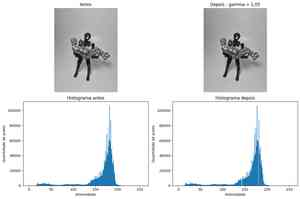

In [14]:
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.imshow(cinza_bem_exposta, cmap='gray', vmin=0, vmax=255)
plt.title('Antes')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(bem_exposta_corrigida, cmap='gray', vmin=0, vmax=255)
plt.title('Depois - gamma = 1,05')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.hist(cinza_bem_exposta.ravel(), bins=256, range=(0, 256))
plt.title('Histograma antes')
plt.xlabel('Intensidade')
plt.ylabel('Quantidade de pixels')

plt.subplot(2, 2, 4)
plt.hist(bem_exposta_corrigida.ravel(), bins=256, range=(0, 256))
plt.title('Histograma depois')
plt.xlabel('Intensidade')
plt.ylabel('Quantidade de pixels')

plt.tight_layout()
plt.show()

## Conclusão

A operação fez menos diferença na **imagem bem exposta**, porque seu histograma já apresentava a maior parte das intensidades na região de tons médios e não mostrava concentração excessiva nos extremos. Por esse motivo foi usado **γ = 1,05**, valor muito próximo de 1, que produz apenas uma pequena alteração. Na **imagem escura**, foi usado **γ = 0,55** para elevar as intensidades baixas e tornar os detalhes mais visíveis. Na **imagem clara/superexposta**, o valor inicialmente considerado, **γ = 1,20**, mostrou-se visualmente pouco efetivo. Após comparação dos resultados, foi adotado **γ = 2,00**, que produziu uma redução perceptível da luminosidade sem escurecer excessivamente as regiões não saturadas. A correção gamma, entretanto, não recupera detalhes de pixels que já atingiram o nível máximo de intensidade durante a captura.